Sections required in your report:

Main objective of the analysis that also specifies whether your model will be focused on a specific type of Deep Learning or Reinforcement Learning algorithm and the benefits that your analysis brings to the business or stakeholders of this data.

Brief description of the data set you chose, a summary of its attributes, and an outline of what you are trying to accomplish with this analysis.

Brief summary of data exploration and actions taken for data cleaning or feature engineering.

Summary of training at least three variations of the Deep Learning model you selected. For example, you can use different clustering techniques or different hyperparameters.

A paragraph explaining which of your Deep Learning models you recommend as a final model that best fits your needs in terms of accuracy or explainability.

Summary Key Findings and Insights, which walks your reader through the main findings of your modeling exercise.

Suggestions for next steps in analyzing this data, which may include suggesting revisiting this model or adding specific data features to achieve a better model.

In [1]:
import warnings
warnings.simplefilter('ignore')

import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow import keras
from keras.datasets import mnist
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense, Embedding, LSTM
import numpy as np
from keras import initializers
from keras.layers import SimpleRNN
from keras.utils import pad_sequences, to_categorical

2025-07-21 14:19:55.459977: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-21 14:19:55.466096: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-21 14:19:55.483103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753107595.511191    1662 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753107595.519742    1662 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753107595.542979    1662 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

MNIST Data Set

1. CNN
2. RNN
3. LSTM

### CNN

In [2]:
# LOAD MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (60000, 28, 28)
60000 train samples
10000 test samples


In [4]:
## Each image is a (28, 28) numpy array
x_train[444].shape

(28, 28)

In [5]:
num_classes = 10

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [6]:
# Normalize !
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [7]:
# reshape dataset to have a single channel
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


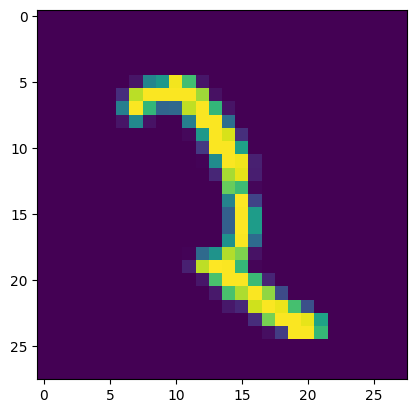

In [8]:
print(y_train[444])
plt.imshow(x_train[444]);

In [9]:
# Let's build a CNN using Keras' Sequential capabilities
model = Sequential()

## 5x5 convolution with 2x2 stride and 28 filters
model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
model.add(Activation('relu'))
## Another 5x5 convolution with 2x2 stride and 28 filters
model.add(Conv2D(28, (5, 5), strides = (2,2)))
model.add(Activation('relu'))
# Add Pooling Layers - reduces params and decreases likelihood of overfitting
model.add(MaxPooling2D(pool_size=(2, 2)))
#Add Dropout Layer — Regularization Technique that randomly drops a percentage of neurons to avoid overfitting)
model.add(Dropout(0.25))
#Add Flatten Layer — Flattens the input as a 1D vector
model.add(Flatten())
# Add Dense Layer — Fully connected layer which performs a linear operation on the layer’s input
model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(10, activation='softmax'))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes))
model.add(Activation('softmax'))

model.summary()

2025-07-18 19:33:09.286974: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 28)     │        22,428 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 11, 11, 28)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 5, 5, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 28)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 700)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        70,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,968 (367.06 KB)

 Trainable params: 93,968 (367.06 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# initiate RMSprop optimizer
opt = keras.optimizers.RMSprop(learning_rate=0.0005)

# Let's train the model using RMSprop
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

model.fit(x_train, y_train,
              batch_size=32,
              epochs=20,
              validation_data=(x_test, y_test),
              shuffle=True)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 146s 77ms/step - accuracy: 0.3127 - loss: 1.9557 - val_accuracy: 0.6878 - val_loss: 1.2724
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 155s 82ms/step - accuracy: 0.3961 - loss: 1.4991 - val_accuracy: 0.8348 - val_loss: 0.9111
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 139s 73ms/step - accuracy: 0.4746 - loss: 1.3925 - val_accuracy: 0.9787 - val_loss: 0.6673
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 128s 68ms/step - accuracy: 0.5245 - loss: 1.2568 - val_accuracy: 0.9839 - val_loss: 0.4565
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 134s 71ms/step - accuracy: 0.5272 - loss: 1.1944 - val_accuracy: 0.9841 - val_loss: 0.3539
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 128s 68ms/step - accuracy: 0.5215 - loss: 1.1852 - val_accuracy: 0.9875 - val_loss: 0.3019
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 130s 70ms/step - accuracy: 0.5271 - loss: 1.1650 - val_accuracy: 0.9876 - val_loss: 0.3099
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 131s 70ms/step - accuracy: 

### RNN

In [11]:
max_features = 20000  # This is used in loading the data, picks the most common (max_features) words
maxlen = 28  # maximum length of a sequence - truncate after this
batch_size = 128
units = 256

In [12]:
# LOAD MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(len(x_train), 'train sequences')
print(len(x_test), 'test sequences')

60000 train sequences
10000 test sequences


In [13]:
# compute the number of labels
num_labels = len(np.unique(y_train))

In [14]:
num_classes = 10

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [15]:
# This pads (or truncates) the sequences so that they are of the maximum length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print('x_train shape:', x_train.shape)
print('x_test shape:', x_test.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)


In [16]:
# Reshape the data !
x_train = x_train.reshape([-1, 28, 28])
x_test = x_test.reshape([-1, 28, 28])

In [17]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [18]:
# model is RNN with 256 units, input is 28-dim vector 28 timesteps
model = Sequential(name='SimpleRNN_MNIST')

model.add(SimpleRNN(units=units,
                    input_shape=(x_train.shape[1],x_train.shape[1])))
model.add(Dense(num_labels, activation='softmax'))
model.summary()

Model: "SimpleRNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 256)            │        72,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,530 (295.04 KB)

 Trainable params: 75,530 (295.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
rmsprop = keras.optimizers.RMSprop(learning_rate = .0001)

model.compile(loss='binary_crossentropy',
              optimizer=rmsprop,
              metrics=['accuracy'])

In [20]:
model.fit(x_train, y_train,
          batch_size=batch_size,
          epochs=20,
          validation_data=(x_test, y_test))

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 178ms/step - accuracy: 0.4518 - loss: 0.2786 - val_accuracy: 0.8547 - val_loss: 0.1110
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 175ms/step - accuracy: 0.8735 - loss: 0.0946 - val_accuracy: 0.9100 - val_loss: 0.0654
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.9198 - loss: 0.0567 - val_accuracy: 0.9311 - val_loss: 0.0468
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 178ms/step - accuracy: 0.9368 - loss: 0.0438 - val_accuracy: 0.9454 - val_loss: 0.0370
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 176ms/step - accuracy: 0.9459 - loss: 0.0365 - val_accuracy: 0.9510 - val_loss: 0.0326
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.9515 - loss: 0.0321 - val_accuracy: 0.9420 - val_loss: 0.0363
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.9563 - loss: 0.0291 - val_accuracy: 0.9605 - val_loss: 0.0257
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 177ms/step - accuracy: 0.9611 - loss: 0

In [21]:
score, acc = model.evaluate(x_test, y_test,
                            batch_size=batch_size)
print('Test score:', score)
print('Test accuracy:', acc)

79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9718 - loss: 0.0178
Test score: 0.015297832898795605
Test accuracy: 0.9761000275611877


### LSTM

In [33]:
# LOAD MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [34]:
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

x_train shape: (60000, 28, 28)
60000 train samples
10000 test samples


In [35]:
# SCALE THE PIXELS
x_train = x_train.astype('float') / 255
x_test = x_test.astype('float') / 255

In [23]:
x_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [24]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [36]:
batch_size = 128
units = 256
# compute the number of labels
num_labels = len(np.unique(y_train))

In [37]:
model = Sequential()
model.add(LSTM(units=units,
               input_shape=(x_train.shape[1:])))
model.add(Dense(num_labels, activation='softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 256)            │       291,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 294,410 (1.12 MB)

 Trainable params: 294,410 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# loss function for one-hot vector
# accuracy is good metric for classification tasks
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [39]:
# train the network
model.fit(x_train, y_train, epochs=20, batch_size=batch_size)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 438s 930ms/step - accuracy: 0.1865 - loss: 2.2698
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 424s 904ms/step - accuracy: 0.3147 - loss: 1.9745
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 408s 870ms/step - accuracy: 0.4650 - loss: 1.6200
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 427s 911ms/step - accuracy: 0.5959 - loss: 1.2238
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 422s 901ms/step - accuracy: 0.7019 - loss: 0.9073
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 426s 908ms/step - accuracy: 0.7627 - loss: 0.7269
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 429s 916ms/step - accuracy: 0.8090 - loss: 0.5997
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 431s 919ms/step - accuracy: 0.8460 - loss: 0.4946
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 424s 905ms/step - accuracy: 0.8738 - loss: 0.4090
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 406s 866ms/step - accuracy: 0.8943 - loss: 0.3435
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 427s 910ms/step - accuracy: 0.9119 - loss: 0.2853
Epoch 12

In [40]:
loss, acc = model.evaluate(x_test, y_test, batch_size=batch_size)
print("\nTest accuracy: %.1f%%" % (100.0 * acc))

79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 333ms/step - accuracy: 0.9581 - loss: 0.1428

Test accuracy: 96.4%
